# **AML 3104 Assignment 2 Campus Recruitment Prediction**
---------------------------------------------------------------------
Student Name: Jennylynne Dominguez

Student Number: C0929140

## Importing Required Libraries

In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, fbeta_score)
from sklearn.ensemble import VotingClassifier

## Loading the dataset train.csv (from https://www.kaggle.com/c/ml-with-python-course-project/data )

In [111]:
df = pd.read_csv("train.csv")  # Adjust path if needed
df.head()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,0,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,0,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,0,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,0,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,0,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0


## Exploratory Data Analysis and Data Preprocessing

In [112]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sl_no           215 non-null    int64  
 1   gender          215 non-null    int64  
 2   ssc_p           215 non-null    float64
 3   ssc_b           215 non-null    object 
 4   hsc_p           215 non-null    float64
 5   hsc_b           215 non-null    object 
 6   hsc_s           215 non-null    object 
 7   degree_p        215 non-null    float64
 8   degree_t        215 non-null    object 
 9   workex          215 non-null    object 
 10  etest_p         215 non-null    float64
 11  specialisation  215 non-null    object 
 12  mba_p           215 non-null    float64
 13  status          215 non-null    object 
 14  salary          148 non-null    float64
dtypes: float64(6), int64(2), object(7)
memory usage: 25.3+ KB


,sl_no,gender,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
count,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,148.000000
mean,108.000000,0.353488,67.303395,66.333163,66.370186,72.100558,62.278186,288655.405405
std,62.209324,0.479168,10.827205,10.897509,7.358743,13.275956,5.833385,93457.452420
min,1.000000,0.000000,40.890000,37.000000,50.000000,50.000000,51.210000,200000.000000
25%,54.500000,0.000000,60.600000,60.900000,61.000000,60.000000,57.945000,240000.000000
50%,108.000000,0.000000,67.000000,65.000000,66.000000,71.000000,62.000000,265000.000000
75%,161.500000,1.000000,75.700000,73.000000,72.000000,83.500000,66.255000,300000.000000
max,215.000000,1.000000,89.400000,97.700000,91.000000,98.000000,77.890000,940000.000000


In [113]:
print(df.isnull().sum())

sl_no              0
gender             0
ssc_p              0
ssc_b              0
hsc_p              0
hsc_b              0
hsc_s              0
degree_p           0
degree_t           0
workex             0
etest_p            0
specialisation     0
mba_p              0
status             0
salary            67
dtype: int64


### Insights:
*   "salary" column has missing values.
*   "sl_no" is just a serial number and can be dropped.
*   Several categorical columns: gender, ssc_b, hsc_b, hsc_s, degree_t, workex, specialisation, status.

## Check for missing values

In [ ]:
missing = df.isnull().sum()
print("Missing values:\n", missing[missing > 0])

median_salary = df['salary'].median() # using median salary to fill missing values
df['salary'] = df['salary'].fillna(median_salary)

Missing values:
 salary    67
dtype: int64


### Why Median?
The median is more robust to outliers and skewness compared to the mean — making it a good default strategy for numerical imputation.

## Label encoding


In [115]:
label_enc = LabelEncoder()
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = label_enc.fit_transform(df[col])

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sl_no           215 non-null    int64  
 1   gender          215 non-null    int64  
 2   ssc_p           215 non-null    float64
 3   ssc_b           215 non-null    int64  
 4   hsc_p           215 non-null    float64
 5   hsc_b           215 non-null    int64  
 6   hsc_s           215 non-null    int64  
 7   degree_p        215 non-null    float64
 8   degree_t        215 non-null    int64  
 9   workex          215 non-null    int64  
 10  etest_p         215 non-null    float64
 11  specialisation  215 non-null    int64  
 12  mba_p           215 non-null    float64
 13  status          215 non-null    int64  
 14  salary          215 non-null    float64
dtypes: float64(6), int64(9)
memory usage: 25.3 KB


,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,0,67.00,1,91.00,1,1,58.00,2,0,55.0,1,58.80,1,270000.0
1,2,0,79.33,0,78.33,1,2,77.48,2,1,86.5,0,66.28,1,200000.0
2,3,0,65.00,0,68.00,0,0,64.00,0,0,75.0,0,57.80,1,250000.0
3,4,0,56.00,0,52.00,0,2,52.00,2,0,66.0,1,59.43,0,265000.0
4,5,0,85.80,0,73.60,0,1,73.30,0,0,96.8,0,55.50,1,425000.0


### Insights
Categorical encoding is necessary during data preprocessing to convert categorical variables into numerical form, which is essential because most machine learning algorithms can only process numerical input.

Categorical features updated are: ssc_b, hsc_b, hsc_s, degree_t, workex, specialisation and status.

##Drop Irrelevant Column "sl_no" since it is irrelevant.

In [116]:
df.drop(columns=['sl_no'], inplace=True)
df.head()

,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,0,67.00,1,91.00,1,1,58.00,2,0,55.0,1,58.80,1,270000.0
1,0,79.33,0,78.33,1,2,77.48,2,1,86.5,0,66.28,1,200000.0
2,0,65.00,0,68.00,0,0,64.00,0,0,75.0,0,57.80,1,250000.0
3,0,56.00,0,52.00,0,2,52.00,2,0,66.0,1,59.43,0,265000.0
4,0,85.80,0,73.60,0,1,73.30,0,0,96.8,0,55.50,1,425000.0


## Visualizations - Histograms

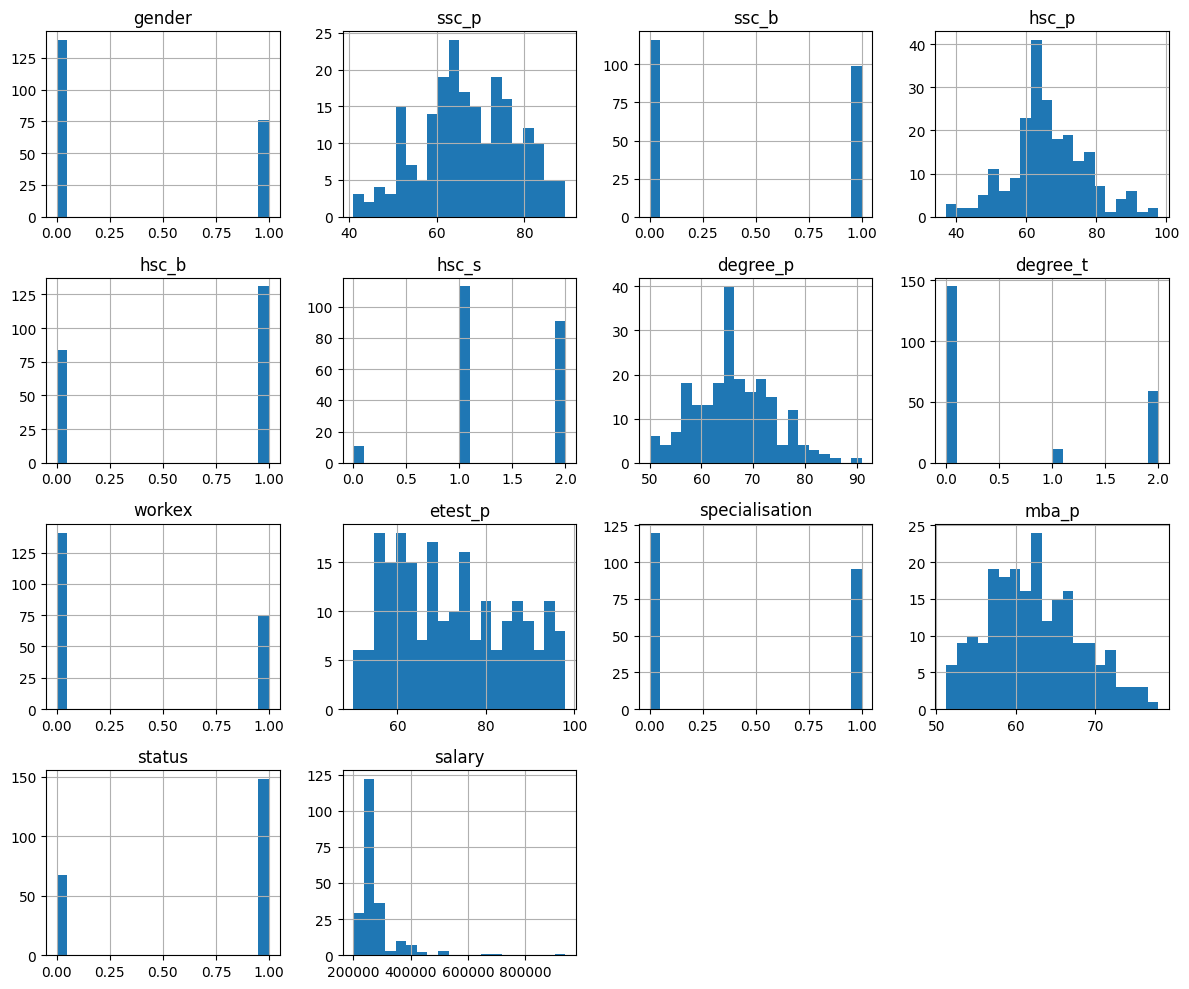

In [117]:
df.hist(figsize=(12, 10), bins=20)
plt.tight_layout()
plt.show()

## Correlation Matrix

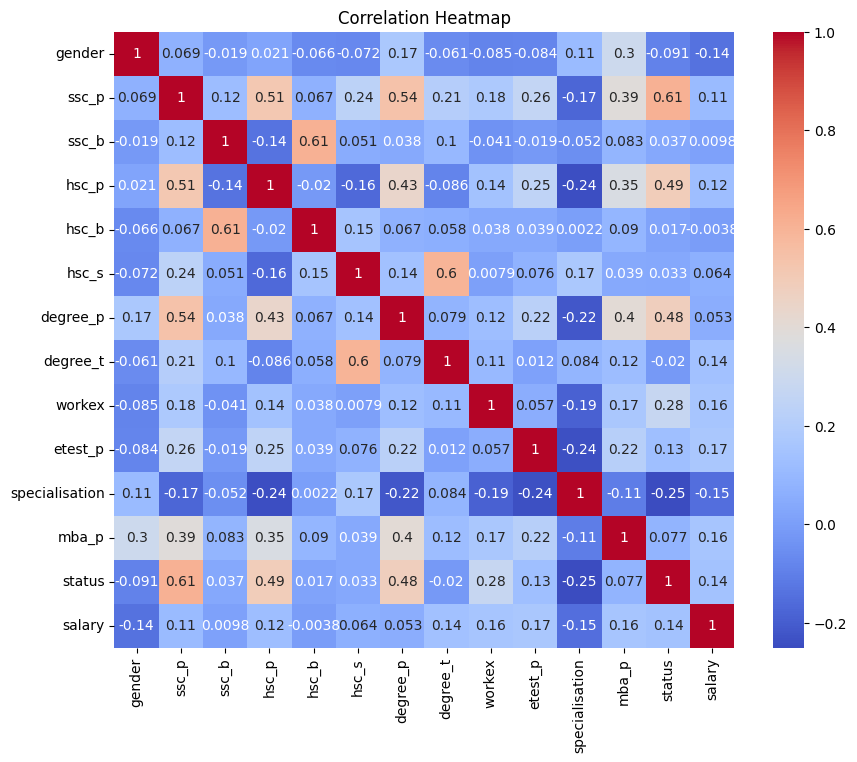

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## Box Plot

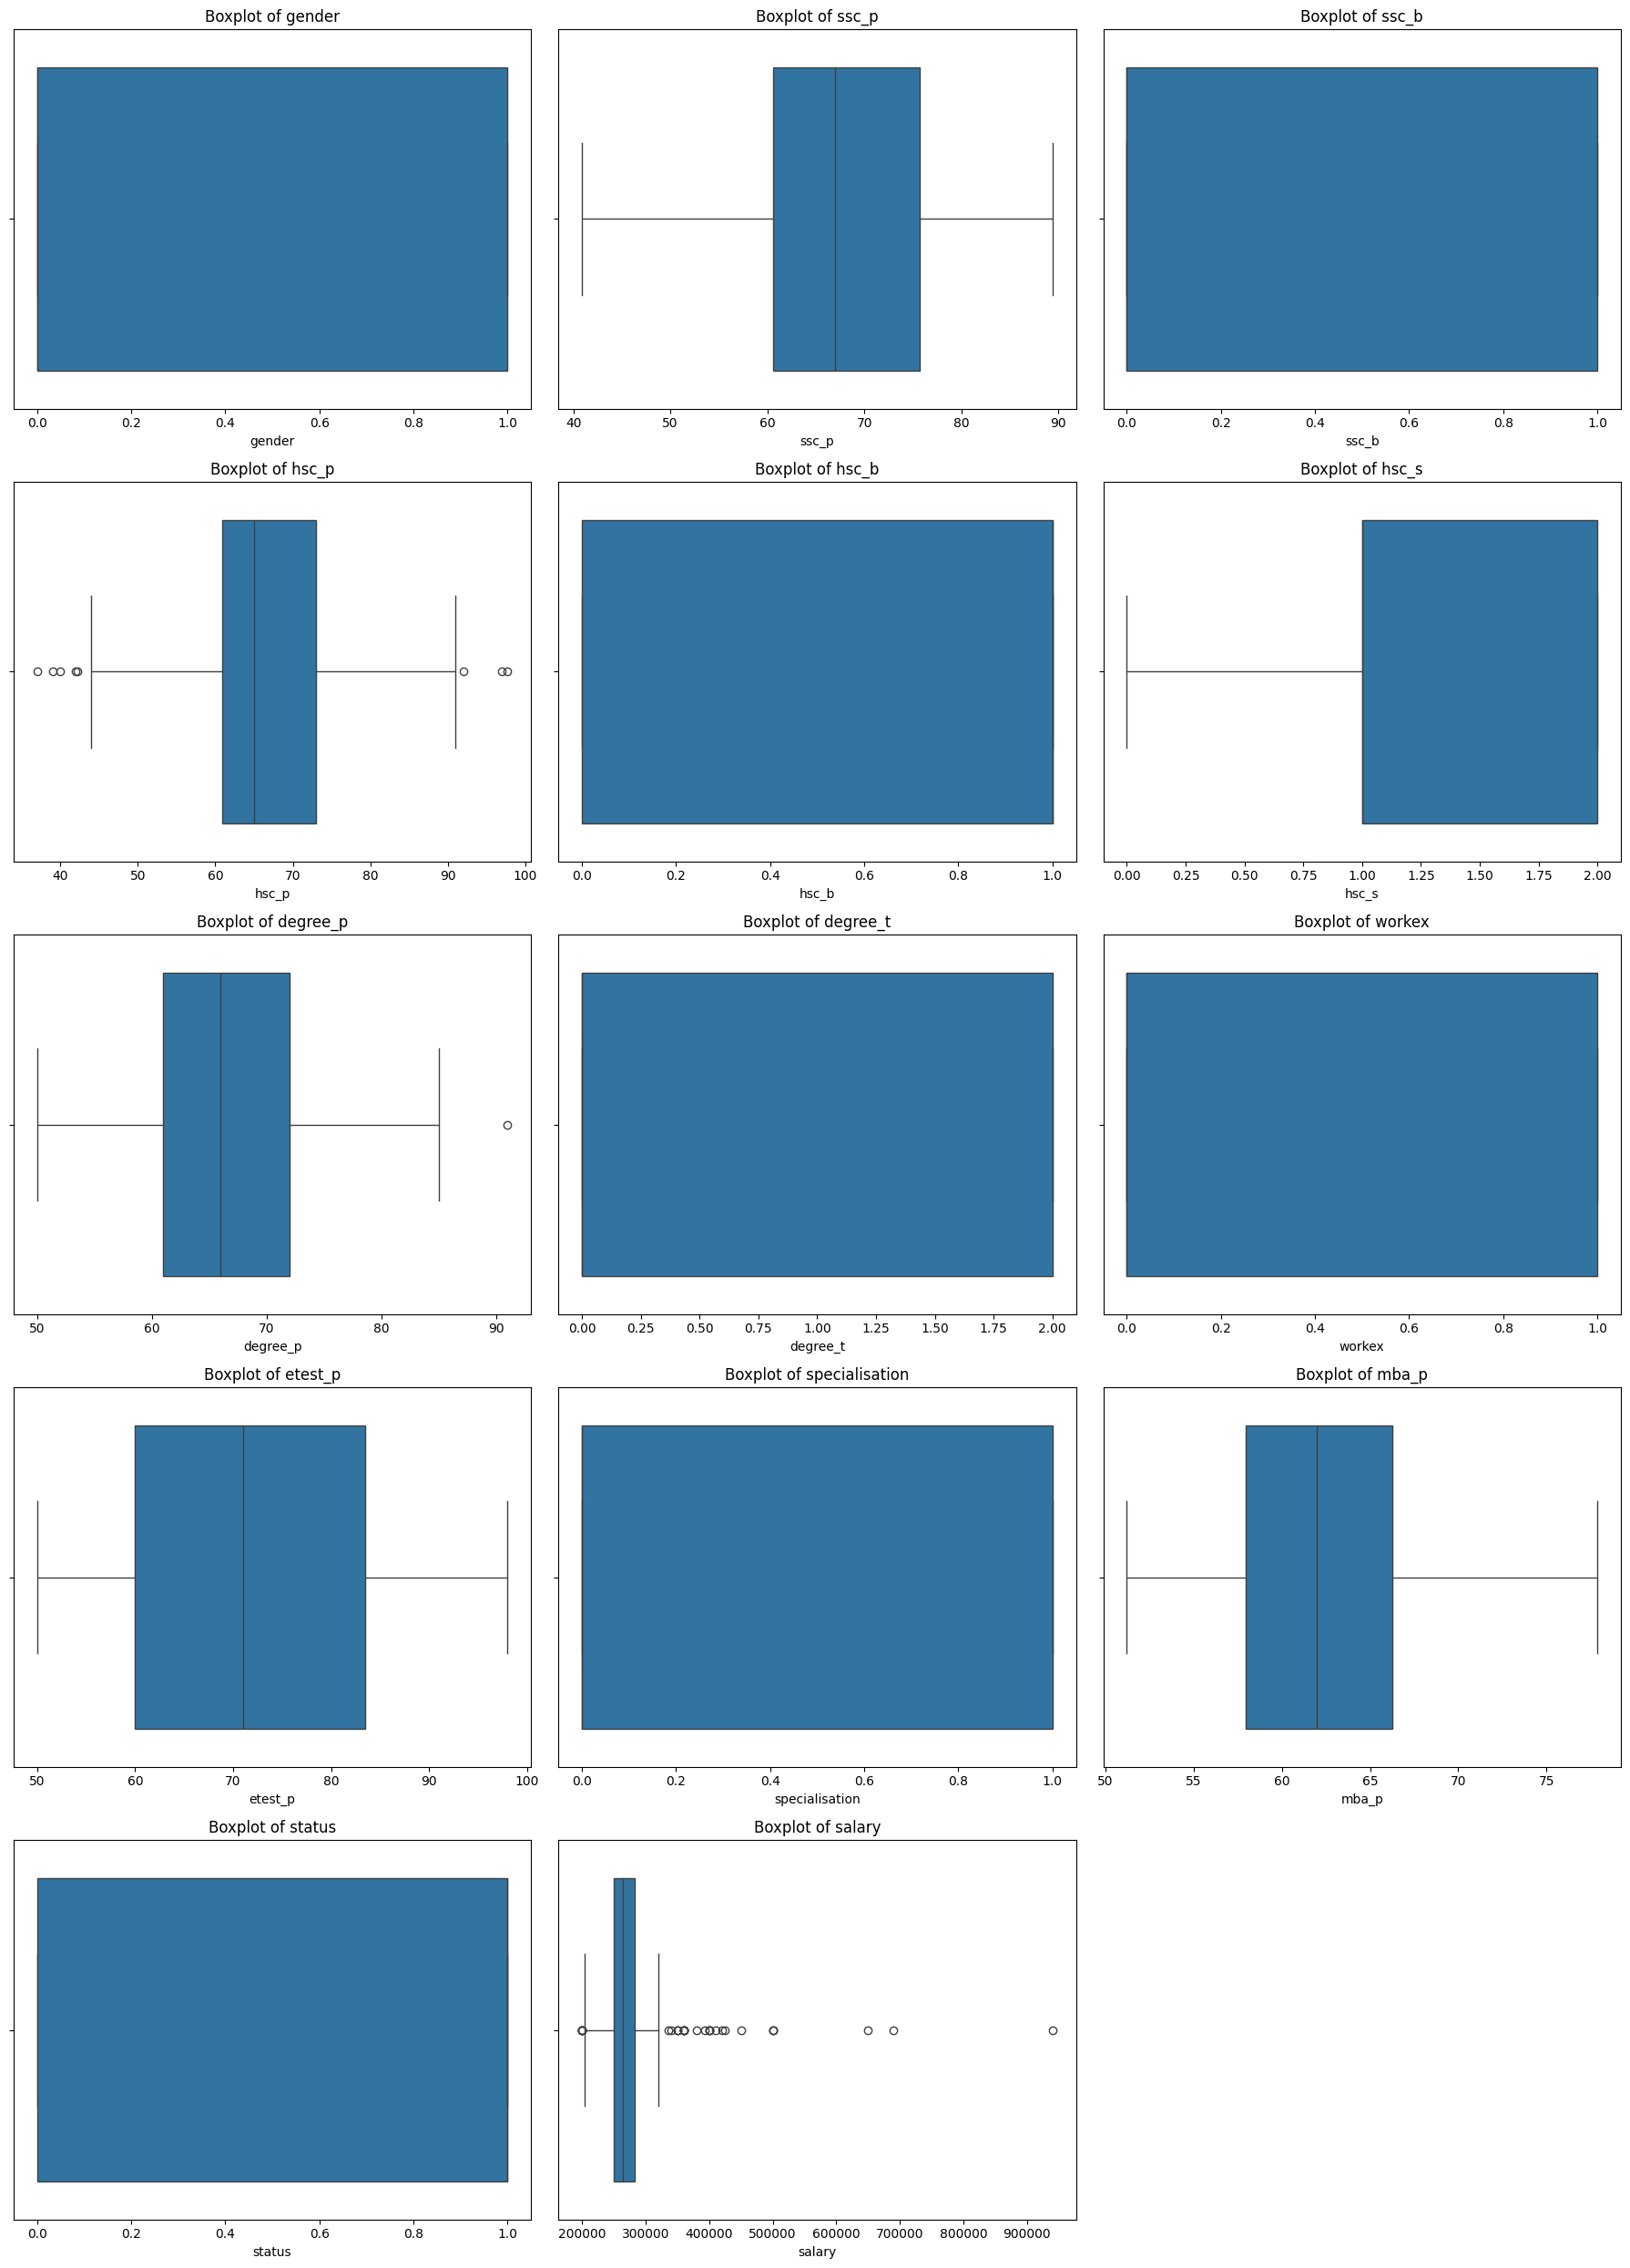

In [ ]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
plot_cols = [col for col in numeric_cols if col != 'sl_no']

num_plots = len(plot_cols)  # calculating required rows 
rows = math.ceil(num_plots / 3)

plt.figure(figsize=(18, 5 * rows))
for i, col in enumerate(plot_cols, 1):
    plt.subplot(rows, 3, i)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()


## Checking of data imbalance

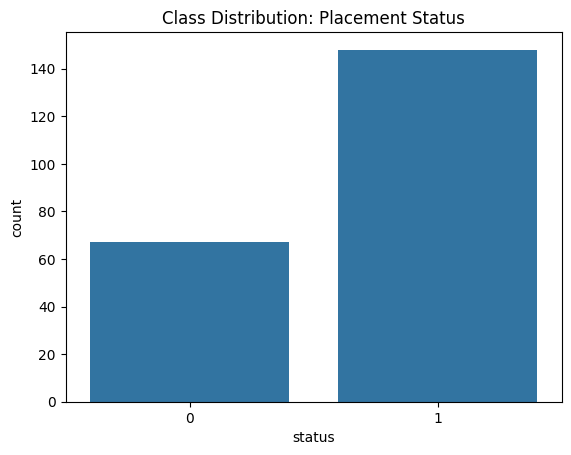

,proportion
status,
1,0.688372
0,0.311628


In [120]:
sns.countplot(x='status', data=df)
plt.title("Class Distribution: Placement Status")
plt.show()

df['status'].value_counts(normalize=True)

### Insights
There is a class imbalance in your target variable (status). Around 70% of students are placed, and only 30% are not placed. The dataset is skewed toward the "Placed" class.

Since the data is imbalance, the model evaluation is highly recommended to use F1-score or F2 score, precision, recall, and confusion matrix to properly evaluate model performance.

## Feature Engineering

In [121]:
df['avg_score'] = df[['ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p']].mean(axis=1)
df['mba_to_degree_ratio'] = df['mba_p'] / (df['degree_p'] + 1e-5)
df['mba_minus_degree'] = df['mba_p'] - df['degree_p']

### Train-Test Split

In [122]:
X = df.drop(columns=['status', 'salary'])
y = df['status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

### Scaling

In [123]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Defining Models + Hyperparameters

In [124]:
models = {
    'Logistic Regression': (
        LogisticRegression(max_iter=1000),
        {'C': [0.01, 0.1, 1, 10]}
    ),
    'SVM': (
        SVC(probability=True),
        {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
    ),
    'Decision Tree': (
        DecisionTreeClassifier(random_state=42),
        {'max_depth': [3, 5, 7, 9]}
    ),
    'Random Forest': (
        RandomForestClassifier(random_state=42),
        {'n_estimators': [50, 100], 'max_depth': [4, 6, 8]}
    )
}

### Training & Evaluation

In [125]:
results = []
conf_matrices = {}

for name, (model, param_grid) in models.items():
    print(f"\nTraining: {name}")
    grid = GridSearchCV(model, param_grid, cv=5, scoring='f1', n_jobs=-1)
    grid.fit(X_train_scaled, y_train)
    best_model = grid.best_estimator_

    # Predictions
    y_train_pred = best_model.predict(X_train_scaled)
    y_test_pred = best_model.predict(X_test_scaled)
    y_train_prob = best_model.predict_proba(X_train_scaled)[:, 1]
    y_test_prob = best_model.predict_proba(X_test_scaled)[:, 1]

    # Store Confusion Matrices
    conf_matrices[name + ' (Train)'] = confusion_matrix(y_train, y_train_pred)
    conf_matrices[name + ' (Test)'] = confusion_matrix(y_test, y_test_pred)

    # Save results
    results.append({
        "Model": name,
        "Best Params": grid.best_params_,
        "Train Accuracy": accuracy_score(y_train, y_train_pred),
        "Train Precision": precision_score(y_train, y_train_pred),
        "Train Recall": recall_score(y_train, y_train_pred),
        "Train F1": f1_score(y_train, y_train_pred),
        "Train F2": fbeta_score(y_train, y_train_pred, beta=2),
        "Train ROC AUC": roc_auc_score(y_train, y_train_prob),
        "Test Accuracy": accuracy_score(y_test, y_test_pred),
        "Test Precision": precision_score(y_test, y_test_pred),
        "Test Recall": recall_score(y_test, y_test_pred),
        "Test F1": f1_score(y_test, y_test_pred),
        "Test F2": fbeta_score(y_test, y_test_pred, beta=2),
        "Test ROC AUC": roc_auc_score(y_test, y_test_prob)
    })


results_df = pd.DataFrame(results)
results_df.sort_values(by="Test F1", ascending=False, inplace=True)
print("\n Train & Test Performance Summary:")
display(results_df)


Training: Logistic Regression

Training: SVM

Training: Decision Tree

Training: Random Forest

 Train & Test Performance Summary:


,Model,Best Params,Train Accuracy,Train Precision,Train Recall,Train F1,Train F2,Train ROC AUC,Test Accuracy,Test Precision,Test Recall,Test F1,Test F2,Test ROC AUC
3,Random Forest,"{'max_depth': 4, 'n_estimators': 50}",0.953333,0.944444,0.990291,0.966825,0.980769,0.989052,0.800000,0.833333,0.888889,0.860215,0.877193,0.853333
0,Logistic Regression,{'C': 0.1},0.920000,0.917431,0.970874,0.943396,0.959693,0.965710,0.769231,0.800000,0.888889,0.842105,0.869565,0.838889
1,SVM,"{'C': 10, 'kernel': 'linear'}",0.913333,0.932692,0.941748,0.937198,0.939922,0.967775,0.769231,0.800000,0.888889,0.842105,0.869565,0.804444
2,Decision Tree,{'max_depth': 7},0.993333,1.000000,0.990291,0.995122,0.992218,0.999793,0.738462,0.780000,0.866667,0.821053,0.847826,0.655000


#Add Voting Classifier (Soft and Hard)

In [126]:
from sklearn.ensemble import VotingClassifier

# Extract best model parameters
lr_params = results_df.loc[results_df['Model'] == 'Logistic Regression', 'Best Params'].values[0]
svm_params = results_df.loc[results_df['Model'] == 'SVM', 'Best Params'].values[0]
dt_params = results_df.loc[results_df['Model'] == 'Decision Tree', 'Best Params'].values[0]
rf_params = results_df.loc[results_df['Model'] == 'Random Forest', 'Best Params'].values[0]

# Rebuild base models
lr_model = LogisticRegression(C=lr_params['C'], max_iter=1000)
svm_model = SVC(C=svm_params['C'], kernel=svm_params['kernel'], probability=True)
dt_model = DecisionTreeClassifier(max_depth=dt_params['max_depth'], random_state=42)
rf_model = RandomForestClassifier(n_estimators=rf_params['n_estimators'], max_depth=rf_params['max_depth'], random_state=42)

# ========== Voting Classifier - Soft ==========
soft_voting = VotingClassifier(
    estimators=[('lr', lr_model), ('svm', svm_model), ('dt', dt_model), ('rf', rf_model)],
    voting='soft'
)
soft_voting.fit(X_train_scaled, y_train)

# Predict and evaluate
def evaluate_model(model, name):
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    y_train_prob = model.predict_proba(X_train_scaled)[:, 1] if hasattr(model, "predict_proba") else None
    y_test_prob = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, "predict_proba") else None

    results_entry = {
        "Model": name,
        "Best Params": "Soft Voting" if "Soft" in name else "Hard Voting",
        "Train Accuracy": accuracy_score(y_train, y_train_pred),
        "Train Precision": precision_score(y_train, y_train_pred),
        "Train Recall": recall_score(y_train, y_train_pred),
        "Train F1": f1_score(y_train, y_train_pred),
        "Train F2": fbeta_score(y_train, y_train_pred, beta=2),
        "Train ROC AUC": roc_auc_score(y_train, y_train_prob) if y_train_prob is not None else "N/A",
        "Test Accuracy": accuracy_score(y_test, y_test_pred),
        "Test Precision": precision_score(y_test, y_test_pred),
        "Test Recall": recall_score(y_test, y_test_pred),
        "Test F1": f1_score(y_test, y_test_pred),
        "Test F2": fbeta_score(y_test, y_test_pred, beta=2),
        "Test ROC AUC": roc_auc_score(y_test, y_test_prob) if y_test_prob is not None else "N/A"
    }

    conf_matrices[name + " (Train)"] = confusion_matrix(y_train, y_train_pred)
    conf_matrices[name + " (Test)"] = confusion_matrix(y_test, y_test_pred)
    return results_entry

soft_result = evaluate_model(soft_voting, "Voting Classifier (Soft)")

# ========== Voting Classifier - Hard ==========
hard_voting = VotingClassifier(
    estimators=[('lr', lr_model), ('svm', svm_model), ('dt', dt_model), ('rf', rf_model)],
    voting='hard'
)
hard_voting.fit(X_train_scaled, y_train)
hard_result = evaluate_model(hard_voting, "Voting Classifier (Hard)")

# Remove any old Voting Classifier rows to avoid duplicates
results_df = results_df[~results_df['Model'].str.contains("Voting Classifier", na=False)]

# Append soft and hard voting results
results_df = pd.concat([results_df, pd.DataFrame([soft_result, hard_result])], ignore_index=True)
results_df.sort_values(by="Test F1", ascending=False, inplace=True)

# Final display
print("\n Final Model Performance (Including Hard and Soft Voting):")
display(results_df)



 Final Model Performance (Including Hard and Soft Voting):


,Model,Best Params,Train Accuracy,Train Precision,Train Recall,Train F1,Train F2,Train ROC AUC,Test Accuracy,Test Precision,Test Recall,Test F1,Test F2,Test ROC AUC
0,Random Forest,"{'max_depth': 4, 'n_estimators': 50}",0.953333,0.944444,0.990291,0.966825,0.980769,0.989052,0.800000,0.833333,0.888889,0.860215,0.877193,0.853333
4,Voting Classifier (Soft),Soft Voting,0.973333,0.962617,1.000000,0.980952,0.992293,0.998554,0.769231,0.777778,0.933333,0.848485,0.897436,0.847778
1,Logistic Regression,{'C': 0.1},0.920000,0.917431,0.970874,0.943396,0.959693,0.96571,0.769231,0.800000,0.888889,0.842105,0.869565,0.838889
2,SVM,"{'C': 10, 'kernel': 'linear'}",0.913333,0.932692,0.941748,0.937198,0.939922,0.967775,0.769231,0.800000,0.888889,0.842105,0.869565,0.804444
5,Voting Classifier (Hard),Hard Voting,0.953333,0.961538,0.970874,0.966184,0.968992,N/A,0.769231,0.812500,0.866667,0.838710,0.855263,N/A
3,Decision Tree,{'max_depth': 7},0.993333,1.000000,0.990291,0.995122,0.992218,0.999793,0.738462,0.780000,0.866667,0.821053,0.847826,0.655


### Confusion Matrices (including VotingClassifier)

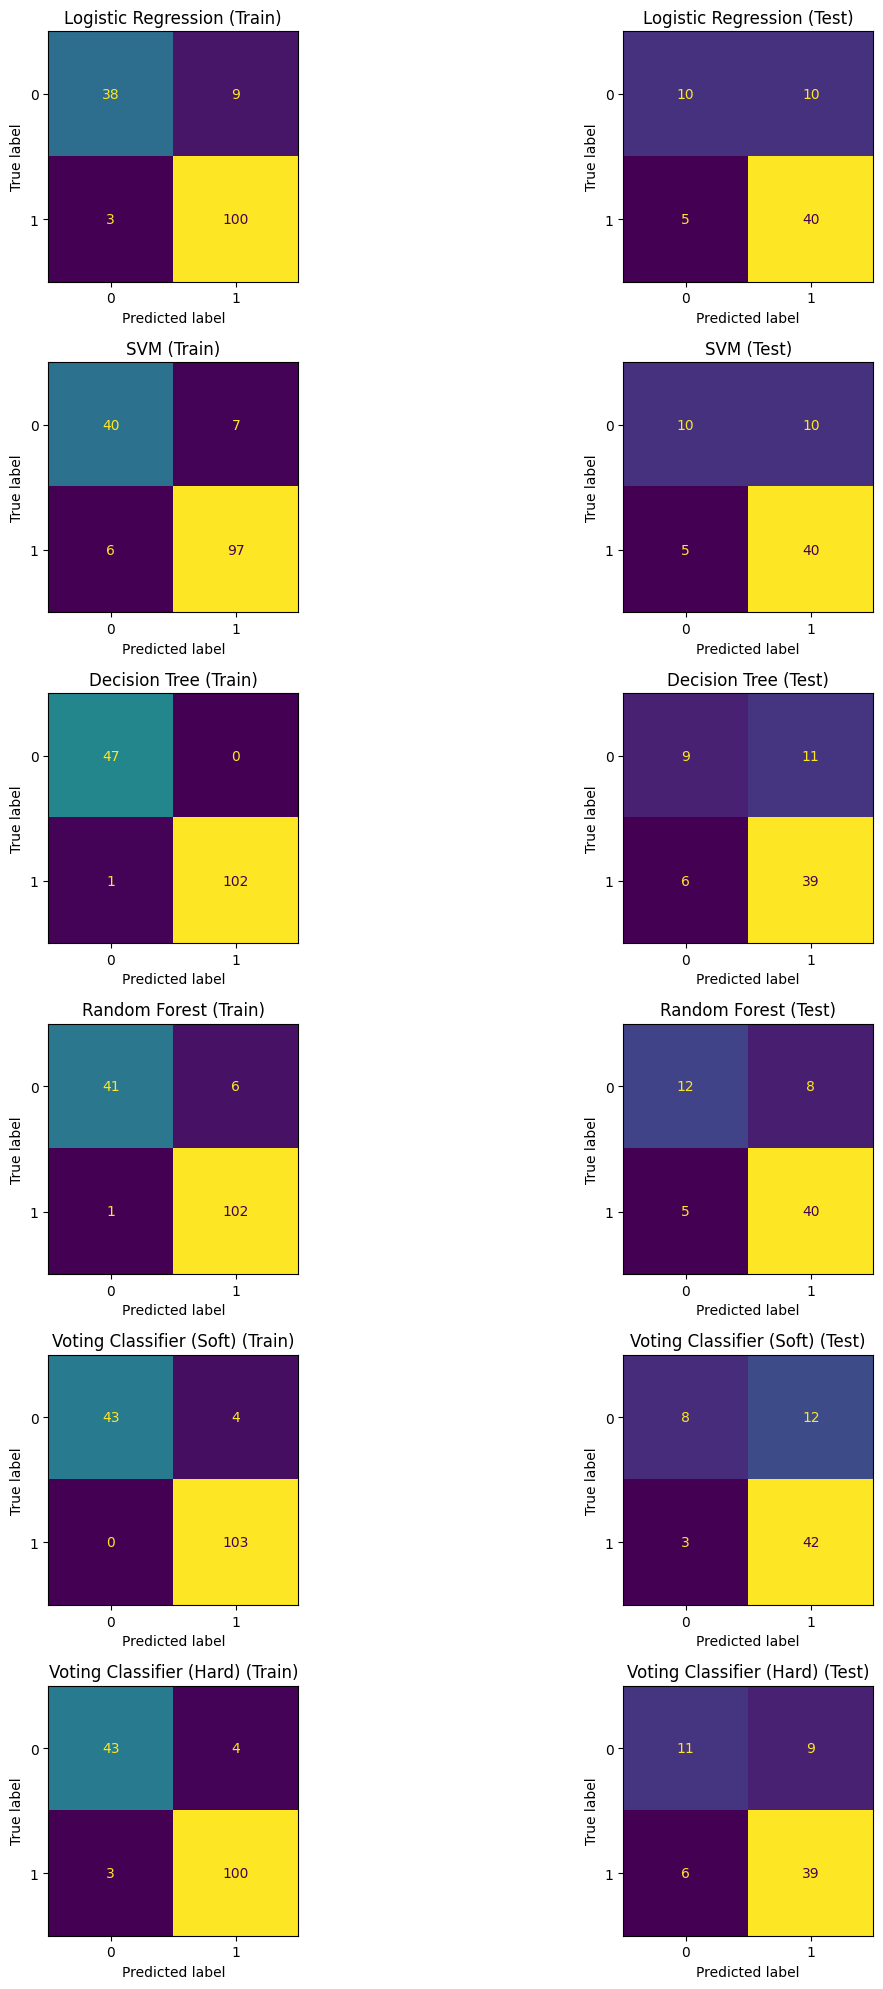

In [127]:
fig, axes = plt.subplots(len(conf_matrices) // 2, 2, figsize=(14, 20))
axes = axes.ravel()

for idx, (title, matrix) in enumerate(conf_matrices.items()):
    ConfusionMatrixDisplay(matrix).plot(ax=axes[idx], colorbar=False)
    axes[idx].set_title(title)

plt.tight_layout()
plt.show()

# Conclusion
Model Performance indicates that Random Forest is the best model for this case scenario aiming to improve placement of student in the academic institution whereby I am aiming to minimize "False Positive"

Goal: Minimize False Positives
False Positive (FP) means predicting a student will be placed, but in reality they won’t.
To reduce FP, i would like to maximize Precision (i.e., only predict "Placed" when you're confident).

Best Model to Reduce False Positives:
- Random Forest (Test Precision: 0.833)

It provides the highest precision, which means it has the lowest rate of false positive predictions among all the models and shows good generalization among other models.